# 24-plaquette SKQD subspace dim (10k shots) and ground state coverage

In [1]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
dirname = '/data/iiyama/heavyhex-qft/plaquette_sim'
filename = 'p{num_plaquettes}_k{kval:.2f}_dt{dtval}_maxdim{max_steps}_shots{shots}.h5'
filename = filename.format(
    num_plaquettes=24, kval=0.8, dtval='{dtval:.2f}', max_steps=16, shots=10000
)

dtvals = [0.1, 0.2, 0.4, 0.6]

dimensions = []
coverages = []
energies = []
for dtval in dtvals:
    with h5py.File(os.path.join(dirname, filename.format(dtval=dtval)), 'r') as source:
        dimensions.append(np.array(source['proj_dimensions']))
        coverages.append(np.array(source['proj_coverage']))
        energies.append(np.array(source['proj_energies']))
        energy_exact = source['ground_energy'][()]

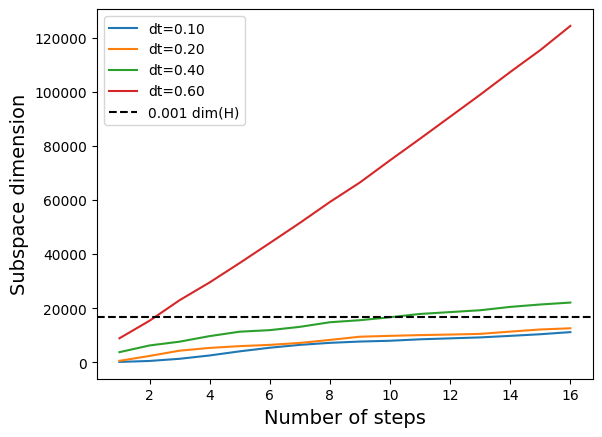

In [3]:
x = np.arange(dimensions[0].shape[0]) + 1
for i, dtval in enumerate(dtvals):
    plt.plot(x, np.mean(dimensions[i], axis=1), label=f'dt={dtval:.2f}')
plt.axhline(2 ** 24 * 0.001, color='black', linestyle='--', label='0.001 dim(H)')
plt.xlabel('Number of steps', fontsize=14)
plt.ylabel('Subspace dimension', fontsize=14)
plt.legend();

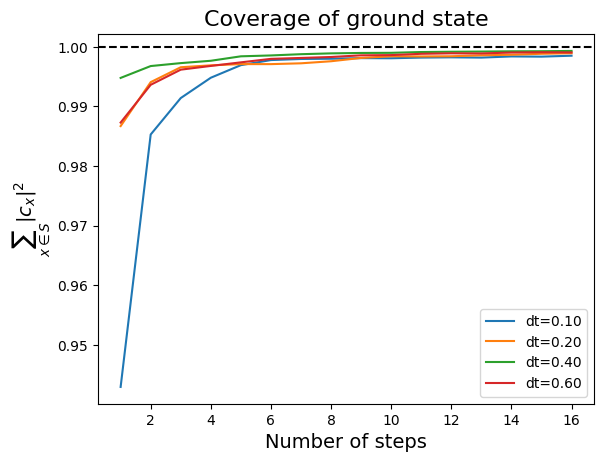

In [4]:
x = np.arange(coverages[0].shape[0]) + 1
for i, dtval in enumerate(dtvals):
    plt.plot(x, np.mean(coverages[i], axis=1), label=f'dt={dtval:.2f}')
plt.axhline(1.0, color='black', linestyle='--')
plt.xlabel('Number of steps', fontsize=14)
plt.ylabel(r'$\sum_{x \in S} |c_x|^2$', fontsize=14)
plt.title('Coverage of ground state', fontsize=16)
plt.legend();

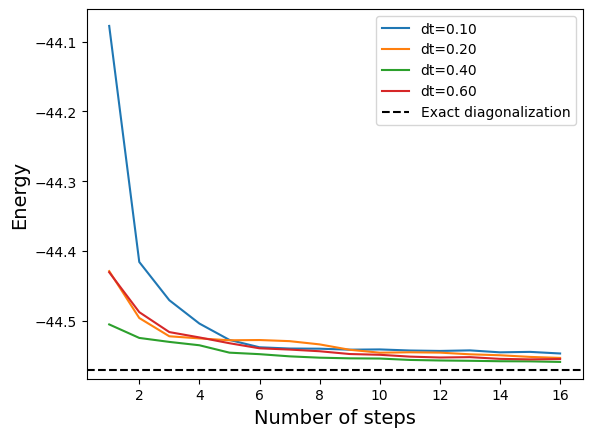

In [5]:
x = np.arange(energies[0].shape[0]) + 1
for i, dtval in enumerate(dtvals):
    plt.plot(x, np.mean(energies[i], axis=1), label=f'dt={dtval:.2f}')
plt.axhline(energy_exact, color='black', linestyle='--', label='Exact diagonalization')
plt.xlabel('Number of steps', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.legend();